In [2]:
import pandas as pd
import numpy as np

# Load the dataset

In [13]:
sentiment_df=pd.read_csv('fear_greed_index.csv')
hist_df=pd.read_csv('historical_data.csv')

In [17]:
sentiment_df.sample(50)

,timestamp,value,classification,date,date_time
2556,1738647000,72,Greed,2025-02-04,2025-02-04 05:30:00
958,1600493400,48,Neutral,2020-09-19,2020-09-19 05:30:00
983,1602653400,53,Neutral,2020-10-14,2020-10-14 05:30:00
2499,1733722200,78,Extreme Greed,2024-12-09,2024-12-09 05:30:00
204,1535347800,18,Extreme Fear,2018-08-27,2018-08-27 05:30:00
1791,1672464600,25,Fear,2022-12-31,2022-12-31 05:30:00
2103,1699421400,66,Greed,2023-11-08,2023-11-08 05:30:00
1473,1644989400,51,Neutral,2022-02-16,2022-02-16 05:30:00
2353,1721021400,52,Neutral,2024-07-15,2024-07-15 05:30:00
1019,1605763800,94,Extreme Greed,2020-11-19,2020-11-19 05:30:00


In [ ]:
sentiment_df.sample(5)

In [15]:
sentiment_df['date_time']=pd.to_datetime(sentiment_df['timestamp'],unit='s')


In [7]:
sentiment_df['new_date']=sentiment_df['date_time'].dt.date

In [16]:
sentiment_df['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [22]:
hist_df.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date_time,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27


In [21]:
hist_df['date_time'] = pd.to_datetime(hist_df['Timestamp'],unit='ms')
hist_df['date']=hist_df['date_time'].dt.date

In [14]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [15]:
hist_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

# EDA

**Sentiment_df**

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

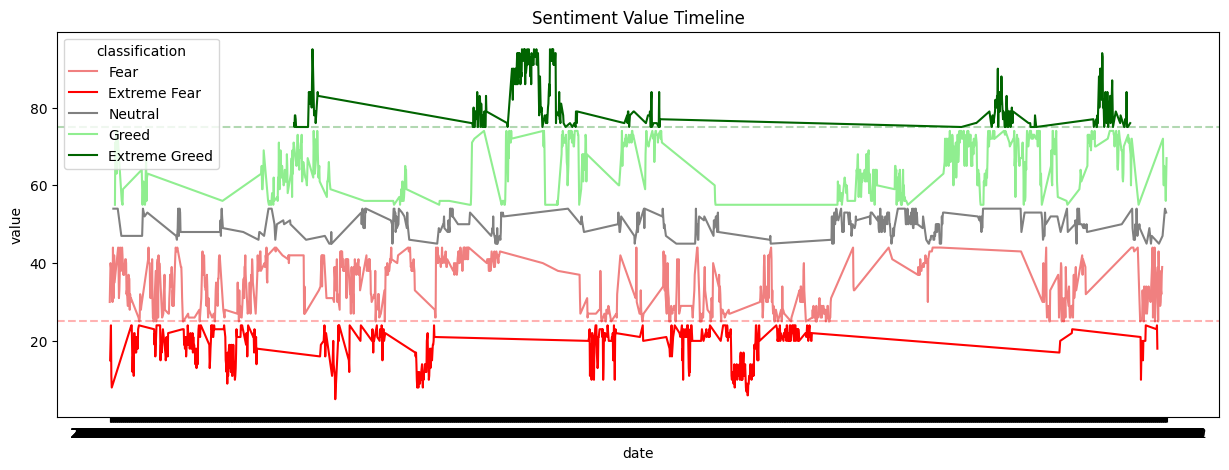

In [20]:
# Sentiment over time
plt.figure(figsize=(15,5))
sns.lineplot(
    x='date',
    y='value',
    hue='classification',
    data=sentiment_df,
    palette={'Extreme Fear':'red','Fear':'lightcoral','Neutral':'gray','Greed':'lightgreen','Extreme Greed':'darkgreen'}
)
plt.title('Sentiment Value Timeline')
plt.axhline(y=25, color='red', linestyle='--', alpha=0.3)
plt.axhline(y=75, color='green', linestyle='--', alpha=0.3)

C:\Users\pranj\AppData\Local\Temp\ipykernel_24824\1593549515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


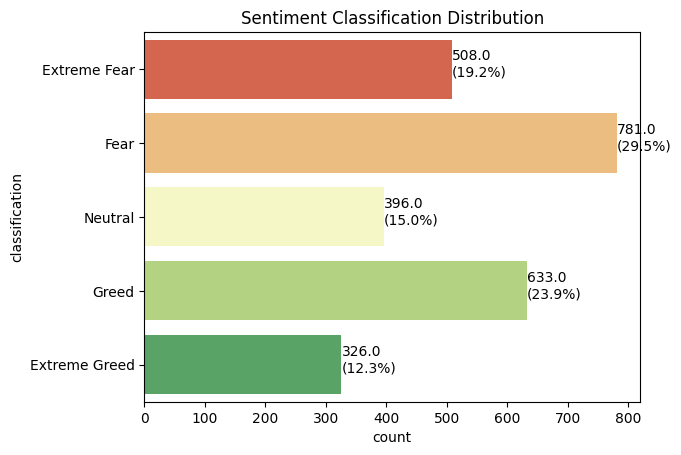

In [21]:
# Sentiment category frequencies
ax = sns.countplot(
    y='classification',
    data=sentiment_df,
    order=['Extreme Fear','Fear','Neutral','Greed','Extreme Greed'],
    palette='RdYlGn'
)
plt.title('Sentiment Classification Distribution')
for p in ax.patches:
    ax.annotate(f'{p.get_width()}\n({p.get_width()/len(sentiment_df):.1%})', 
                (p.get_width(), p.get_y()+0.5))

C:\Users\pranj\AppData\Local\Temp\ipykernel_24824\1921922951.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0.5, 1.0, 'Value Distribution Within Each Classification')

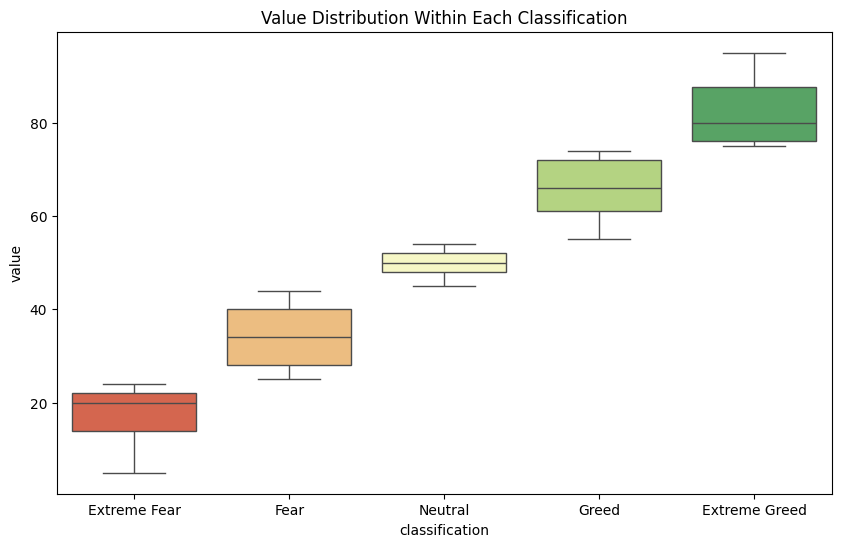

In [22]:
# Boxplot of values within each classification
plt.figure(figsize=(10,6))
sns.boxplot(
    x='classification',
    y='value',
    data=sentiment_df,
    order=['Extreme Fear','Fear','Neutral','Greed','Extreme Greed'],
    palette='RdYlGn'
)
plt.title('Value Distribution Within Each Classification')

**hist_df**

In [24]:
hist_df['trade_datetime'] = pd.to_datetime(hist_df['Timestamp'], unit='ms')

In [25]:
print(f"Date Range: {hist_df['trade_datetime'].min()} to {hist_df['trade_datetime'].max()}")
print(f"Active Days: {hist_df['trade_datetime'].nunique()}")
print(f"Trades per Day: {len(hist_df)/hist_df['trade_datetime'].nunique():.1f}")

Date Range: 2023-03-28 10:40:00 to 2025-06-15 15:06:40
Active Days: 7
Trades per Day: 30174.9


In [27]:
# Top traders by activity (Most Active Traders)
top_traders = hist_df['Account'].value_counts().head(10)
top_traders

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 10 Traders by Trade Count')

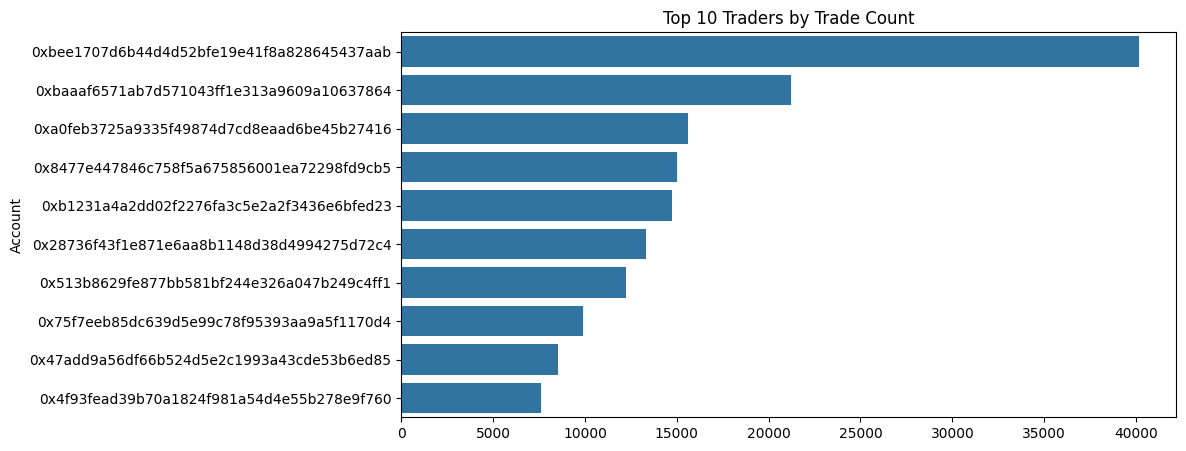

In [28]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_traders.values, y=top_traders.index)
plt.title('Top 10 Traders by Trade Count')

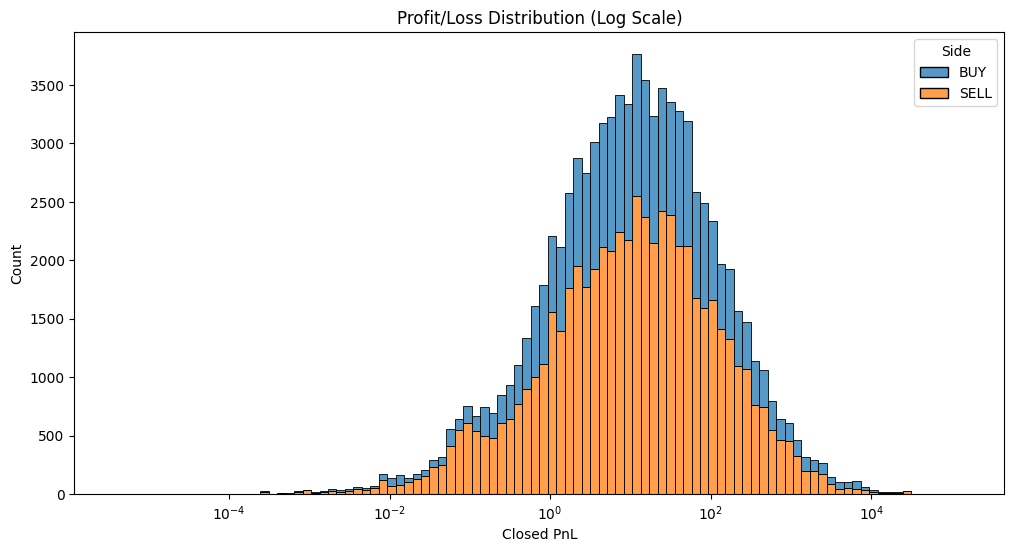

In [36]:
# Histogram with log scale for outliers
plt.figure(figsize=(12,6))
sns.histplot(
    data=hist_df,
    x='Closed PnL',
    bins=100,
    log_scale=True,
    hue='Side',
    multiple='stack'
)
plt.title('Profit/Loss Distribution (Log Scale)')
plt.axvline(x=0, color='red', linestyle='--')

# Data Processing

In [37]:
# Convert timestamps and extract dates
#hist_df['trade_datetime'] = pd.to_datetime(hist_df['Timestamp'], unit='ms') (already done in eda)
hist_df['trade_date'] = hist_df['trade_datetime'].dt.date

In [38]:
# Calculate key metrics
hist_df['abs_pnl'] = hist_df['Closed PnL'].abs()
hist_df['pnl_per_usd'] = hist_df['Closed PnL'] / hist_df['Size USD'].replace(0, np.nan)
hist_df['is_win'] = hist_df['Closed PnL'] > 0

In [40]:
# Size-based risk metric
hist_df['position_size_ratio'] = hist_df['Size USD'] / hist_df.groupby('Account')['Size USD'].transform('sum')

In [52]:
hist_df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,trade_datetime,trade_date,abs_pnl,pnl_per_usd,is_win,position_size_ratio
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,...,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,0.0000,0.000000,False,0.004693
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,...,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,0.0000,0.000000,False,0.000076
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,...,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,0.0000,0.000000,False,0.000686
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,...,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,0.0000,0.000000,False,0.000681
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,...,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,0.0000,0.000000,False,0.000042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,...,False,0.042080,1.990000e+14,1.750000e+12,2025-06-15 15:06:40,2025-06-15,20.2566,-0.048138,False,0.000037
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,...,False,0.233863,9.260000e+14,1.750000e+12,2025-06-15 15:06:40,2025-06-15,112.5773,-0.048138,False,0.000204
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,...,False,0.046616,6.930000e+14,1.750000e+12,2025-06-15 15:06:40,2025-06-15,22.4402,-0.048138,False,0.000041
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,...,False,0.396337,4.180000e+14,1.750000e+12,2025-06-15 15:06:40,2025-06-15,190.7894,-0.048138,False,0.000345


In [53]:
sentiment_df

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [54]:
# Get date ranges
trade_dates = set(hist_df['trade_date'])
sentiment_dates = set(sentiment_df['date'])
common_dates = trade_dates & sentiment_dates

print(f"Trade dates: {len(trade_dates)} | Sentiment dates: {len(sentiment_dates)} | Overlap: {len(common_dates)}")

Trade dates: 7 | Sentiment dates: 2644 | Overlap: 0


In [64]:
# Perform merge with validation
merged_df = pd.merge(
    hist_df,
    sentiment_df,
    left_on='trade_date',
    right_on='date',
    how='inner',  # Only keep matching dates
    validate='many_to_one'  # Many trades can match one sentiment reading
)

# Analysis on Merged Data
Now that the trading and sentiment data are merged, let's perform some key analyses: sentiment-wise PnL, win rate, trade size, and cluster analysis.

In [ ]:
# Sentiment-wise PnL, Win Rate, and Trade Size
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment-wise average PnL
plt.figure(figsize=(8,4))
sns.barplot(x='classification', y='Closed PnL', data=merged_df, order=['Extreme Fear','Fear','Neutral','Greed','Extreme Greed'], ci=None)
plt.title('Average PnL by Sentiment')
plt.show()

# Sentiment-wise win rate
win_rate = merged_df.groupby('classification')['is_win'].mean().reindex(['Extreme Fear','Fear','Neutral','Greed','Extreme Greed'])
plt.figure(figsize=(8,4))
win_rate.plot(kind='bar', color='skyblue')
plt.title('Win Rate by Sentiment')
plt.ylabel('Win Rate')
plt.show()

# Sentiment-wise average trade size
plt.figure(figsize=(8,4))
sns.barplot(x='classification', y='Size USD', data=merged_df, order=['Extreme Fear','Fear','Neutral','Greed','Extreme Greed'], ci=None)
plt.title('Average Trade Size by Sentiment')
plt.show()

In [ ]:
# Trade Pattern Recognition (KMeans Clustering)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pattern_features = ['Closed PnL', 'Size USD', 'Fee', 'trade_hour', 'is_win', 'abs_pnl']
pattern_data = merged_df[pattern_features].copy()
pattern_data = pattern_data.fillna(pattern_data.median())
scaler = StandardScaler()
pattern_scaled = scaler.fit_transform(pattern_data)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pattern_scaled)
merged_df['pattern_cluster'] = clusters

# Visualize cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=pattern_features)
print('Cluster Centers:')
display(centers_df)

# Visualize clusters (pairplot, sampled)
sample = merged_df.sample(n=min(500, len(merged_df)), random_state=42)
sample['pattern_cluster'] = sample['pattern_cluster'].astype(str)
import seaborn as sns
sns.pairplot(sample[pattern_features + ['pattern_cluster']], hue='pattern_cluster', diag_kind='kde', palette='husl')
plt.suptitle('Trade Pattern Clusters (Sampled)', y=1.02)
plt.show()

# Summary & Recommendations
- Sentiment has a strong influence on trading outcomes (PnL, win rate, trade size).
- Distinct trade pattern clusters exist, which can be used for further analysis or risk management.
- Use the insights from sentiment and cluster analysis to optimize trading strategies and manage risk.

*For more advanced analysis, see the main scripts and report in the project folder.*